In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import re
import scipy.stats as ss

import warnings
warnings.simplefilter('ignore')
#opt+up/down to move cell up/down

sns.set_context('talk')

In [184]:
# folder = 'expl'
folder = 'conf'

mname = 'realPrediction_lrdecay_peppgFull_econ_ThetaGamma_arbWeight_llh'

In [185]:
def get_performance_df(df_idv, df_group, save_folder):
    #organize performance df
    idv_risk = df_idv.loc[df_idv.trial>60].groupby(['subID', 'predatorType'], as_index=False)[['choice', 'reward', 'attack']].mean()
    idv_risk = idv_risk.rename({'attack': 'idv_attack'}, axis=1)
    # grp_risk = df_group.loc[df_group.step_rt<8].groupby(['sub', 'predatorType', 'room'], as_index=False)[['playerStep', 'jointMoney', 'finalStep', 'selfBlame','playerKeep2', 'partnerStep', 'attack']].mean()
    df_group['attack'] = df_group['attack'].astype(bool)
    grp_risk = df_group.query('step_rt<8 and playerStep>0').groupby(['subID', 'predatorType', 'room'],
                                                        as_index=False)[['playerStep', 'jointMoney', 'finalStep','partnerStep', 'attack']].mean()

    g = pd.merge(idv_risk, grp_risk)
    g = g.sort_values(by=['room', 'predatorType', 'choice'])
    #append local and global riskiness
    g['risky_wpair'] = ['lower', 'higher'] * (2*len(g.room.unique()))
    g['risky_abs'] = g.apply(lambda x: 'high' if ((x['predatorType']==0 and x['choice']>=6.5) or (x['predatorType']==1 and x['choice']>=4.5)) else 'low', axis=1)
    #get group idn choice diff
    g['grp_idv_step_diff'] = g['playerStep'] - g['choice']
    g['jointMoney'] = g['jointMoney'] /2
    #get self partner risk diff
    g['grp_idv_reward_diff'] = g['jointMoney'] - g['reward']
    g['grp_idv_attack_diff'] = g['attack'] - g['idv_attack']
    g['self_partner_risk_diff'] = g.groupby(['room', 'predatorType'])['choice'].diff()
    g['self_partner_risk_diff'] = g.groupby(['room', 'predatorType'])['self_partner_risk_diff'].transform(lambda x: x.fillna(-x.iloc[-1]))

    #get mean abs ppd and pe
    t = df_group.groupby(['subID', 'predatorType'], as_index=False
                        )['player_partner_diff'].apply(lambda x: np.mean(np.absolute(x)))
    g = pd.merge(t, g)
    df_group['pred_partner_diff'] = df_group['prediction'] - df_group['partnerStep']
    t = df_group.loc[df_group.prediction!=-1].groupby(['subID', 'predatorType'], as_index=False)['pred_partner_diff'].apply(lambda x: np.mean(np.absolute(x)))
    g = pd.merge(g, t)

    # #get blame and blame asynchrony
    t = df_group.query('selfBlame!=-1').groupby(['room', 'trial', 'predatorType'], 
                                                as_index=False)['selfBlame'].sum()
    t['blame_async'] = np.absolute(1 - t['selfBlame'])
    t = t.groupby('room', as_index=False)['blame_async'].mean()
    g = pd.merge(t, g, how='right')
    t = df_group.query('selfBlame!=-1').groupby(['room', 'predatorType'], 
                                                as_index=False)['selfBlame'].mean()
    g = pd.merge(t, g, how='right')

    #get variance. maybe better to used the first 60 rounds in idv?
    grp_unc = df_group.groupby(['subID', 'predatorType', 'room'], as_index=False)[['playerStep', 'partnerStep']].var()
    grp_unc = grp_unc.rename({'playerStep': 'playerStep_var', 'partnerStep': 'partnerStep_var'}, axis=1)
    idv_unc= df_idv.loc[df_idv.trial>=60].groupby(['subID', 'predatorType'], as_index=False)['choice'].var()
    idv_unc = idv_unc.rename({'choice': 'idvStep_var'}, axis=1)
    g = pd.merge(pd.merge(g, grp_unc), idv_unc)
    g = g.rename({'reward':'idvMoney', 'choice':'idvStep', 'player_partner_diff':'abs_player_partner_diff', 'pred_partner_diff':'abs_prediction_error'}, axis=1)

    #append variance of ppd and final step
    t = df_group.loc[df_group.playerID==0].copy()
    t['abs_ppd'] = np.absolute(t['player_partner_diff'])
    grp_var = t.groupby(['predatorType', 'room'], as_index=False)[['finalStep', 'abs_ppd']].var()
    grp_var = grp_var.rename({'finalStep':'finalStep_var', 'abs_ppd':'abs_ppd_var'}, axis=1)
    g = pd.merge(g, grp_var, how='left')

    g.to_csv(f'../processed_data/group_perf_{save_folder}.csv')
    return g


In [186]:
if folder == 'conf':
    #read qs
    qs1 = pd.read_csv("../processed_data/parsed_questionnaire_rep2.csv")
    qs1['subID'] = qs1['subID'] + 400
    qs_orig = pd.concat([qs1,
        pd.read_csv("../processed_data/parsed_questionnaire_conf.csv")
    ]) 
    #read data
    df_group1 = pd.read_csv("../processed_data/parsed_group_rep2.csv")
    df_group1['room'] = df_group1['room'] + 200
    df_group1['subID'] = df_group1['subID'] + 400

    df_group2 = pd.read_csv("../processed_data/parsed_group_conf.csv")
    df_group = pd.concat([df_group1, df_group2])

    df_idv1 = pd.read_csv("../processed_data/parsed_idv_rep2.csv")
    df_idv1['subID'] = df_idv1['subID'] + 400

    df_idv2 = pd.read_csv("../processed_data/parsed_idv_conf.csv")
    df_idv = pd.concat([df_idv1, df_idv2])

    # overall stats
    df_perf1 = get_performance_df(df_idv1, df_group1, 'rep2')
    df_perf2 = get_performance_df(df_idv2, df_group2, 'conf')
    df_perf = pd.concat([df_perf1, df_perf2])

    # read model
    m_grp1 = pd.read_csv(f"../model_fits/rl_rep2/{mname}.csv")
    m_grp1['subID'] = m_grp1['subID'] + 400
    m_grp = pd.concat([pd.read_csv(f"../model_fits/rl_conf/{mname}.csv"), m_grp1])

    
elif folder == 'expl':
    #read qs
    qs_orig = pd.read_csv('../processed_data/parsed_questionnaire_expl.csv')
    #read data
    df_group = pd.read_csv('../processed_data/parsed_group_expl.csv')
    df_idv = pd.read_csv('../processed_data/parsed_idv_expl.csv')
    # overall stats
    df_perf = get_performance_df(df_idv, df_group, 'expl')
    # read model
    m_grp = pd.read_csv(f"../model_fits/rl_expl/{mname}.csv")
    




In [187]:
# qs1 = pd.read_csv("../processed_data/parsed_questionnaire_rep2.csv", index_col=[0])
# qs1['subID'] = qs1['subID'] + 400
# qs_orig = pd.concat([qs1,
#     , index_col=[0])
# ]) 




In [188]:
# print(len(qs_orig))
# qs_orig = pd.read_csv("../processed_data/parsed_questionnaire_expl.csv")
# qs_orig2 = pd.merge(qs_orig, df_group[['subID', 'sub']].drop_duplicates(), how='inner')

# print(len(qs_orig2))
# qs_orig2.to_csv('../processed_data/parsed_questionnaire_expl.csv')
# qs_orig2.query('subID != subID')

In [189]:
print(f"{len(qs_orig['subID'].unique())} subjects with {len(qs_orig)} rows")
qs_orig.head()

470 subjects with 470 rows


,Unnamed: 0,ptn_rating,svo_value,svo_type,utility,trait,ius_score,subID
0,0,7,37.482411,prosocial,20.0,26,43,416
1,1,10,37.092837,prosocial,inf,32,33,461
2,2,7,19.712032,individualistic,20.0,47,60,446
3,3,9,35.011535,prosocial,12.0,30,53,413
4,4,9,24.523477,prosocial,20.0,33,56,450


In [190]:
qs_subs = qs_orig['subID'].unique()
df_group.query('subID not in @qs_subs')['subID'].unique()

array([458, 430, 463, 414, 462, 489, 444, 400, 502, 547, 517, 580, 595,
       607, 594, 577,   1,   2,   3,  21,  42,  68,  80,  87,  89, 103,
       121, 122, 127, 141, 151, 162, 169, 171, 172, 174, 176, 191, 227,
       254, 255, 263, 265, 301])

In [191]:
# c = qs_orig.groupby(['subID'])['sub'].count()
# c[c>1]
# qs_orig.query('subID==208')

In [192]:

# subs = df_group['sub'].unique()
# id_mapping = dict(zip(subs, range(len(subs))))
# df_group['subID'] = df_group['sub'].apply(lambda x: id_mapping[x])
# df_idv = df_idv.query('sub in @subs')
# df_idv['subID'] = df_idv['sub'].apply(lambda x: id_mapping[x])
print(len(df_group['subID'].unique()))
df_group.columns

514


Index(['attack', 'selfBlame', 'jointMoney', 'partnerStep', 'playerStep',
       'prediction', 'share', 'split_rt', 'step_rt', 'trial', 'room', 'block',
       'playerID', 'predatorType', 'player_partner_diff', 'finalStep', 'subID',
       'predatorAttack', 'playerKeep', 'confidence', 'playerKeep2', 'payoff'],
      dtype='object')

In [193]:
# some people completed the questionnaire without doing the task
# qs_orig.query('sub not in @intersection')

In [194]:
#read data parsed from analyze_data_nofbwblame

#merge to get subID
data = pd.merge(df_perf, qs_orig, on='subID')
data['predator'] = data['predatorType'].apply(lambda x: 'low-threat' if x==0 else 'high-threat')
print(f"{len(data['subID'].unique())} subjects with {len(data)} rows")
# data.columns

470 subjects with 940 rows


# Correlation 


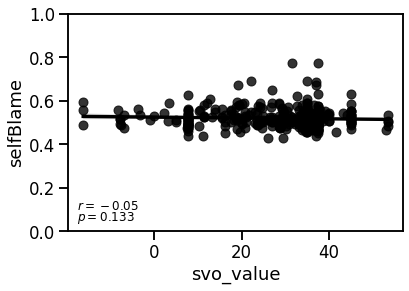

<Figure size 432x288 with 0 Axes>

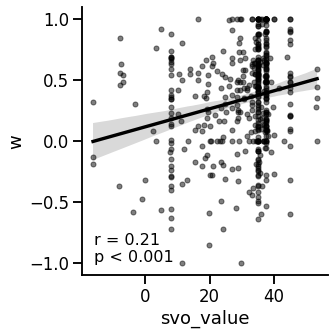

In [195]:
# # svo
# sns.regplot(data = data, x='svo_value', y='playerKeep2', color='black')
# plt.ylabel('player selfishness')
# plt.ylim([0, 1.1])
# r_value, p_value = ss.pearsonr(data['svo_value'], data['playerKeep2'])
# #annotate
# myleft = (plt.gca().get_xlim()[0]) *0.9
# plt.text(myleft, 0.1, f'$r = {r_value:.2f}$', fontsize=12)
# if p_value>=0.001:
#     plt.text(myleft, 0.05, f'$p = {p_value:.2g}$', fontsize=12)
# else:
#     plt.text(myleft, 0.05, f'$p < 0.001$', fontsize=12)


plt.figure()
d = data.groupby(['subID', 'svo_value'], as_index=False)['selfBlame'].mean()
sns.regplot(data = d, x='svo_value', y='selfBlame', color='black')
plt.ylim([0, 1])
r_value, p_value = ss.pearsonr(data['svo_value'], data['selfBlame'])
#annotate
myleft = (plt.gca().get_xlim()[0]) *0.9
plt.text(myleft, 0.1, f'$r = {r_value:.2f}$', fontsize=12)
if p_value>=0.001:
    plt.text(myleft, 0.05, f'$p = {p_value:.3f}$', fontsize=12)
else:
    plt.text(myleft, 0.05, f'$p < 0.001$', fontsize=12)


# with w
plt.figure()
d = pd.merge(data,  m_grp)[['subID', 'svo_value', 'w']].drop_duplicates()
sns.lmplot(data = d, x='svo_value', y='w', 
scatter_kws={'color':'black', 's':25, 'alpha':0.5}, line_kws={'color':'black'})

# plt.ylim([0, 1])
r_value, p_value = ss.pearsonr(d['svo_value'], d['w'])
p_txt = f'= {round(p_value, 3)}' if p_value>0.001 else ' < 0.001'
# annotate r
plt.annotate(
    f'r = {r_value:.2f}\np{p_txt}',
    xy=(0.05, 0.05),
    xycoords='axes fraction',
    fontsize=16
)
plt.savefig(f'../paper_figs/{folder}/w_svo_{folder}.png', 
            dpi=200, bbox_inches='tight')

In [196]:
# regression: blame ~ svo + player_partner_diff * attack

import statsmodels.formula.api as smf
test = df_group.query('selfBlame!=-1')
test = pd.merge(test, data[['subID', 'svo_value']])
# Run the regression using the formula
model = smf.ols(formula='selfBlame ~ svo_value * attack + player_partner_diff * attack', data=test,
                groups = test['subID'])

result = model.fit()

# Print the summary of the model
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:              selfBlame   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     2337.
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        13:59:25   Log-Likelihood:                 11443.
No. Observations:               55578   AIC:                        -2.287e+04
Df Residuals:                   55572   BIC:                        -2.282e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [165]:
df_perf.columns

Index(['room', 'predatorType', 'selfBlame', 'blame_async', 'subID',
       'abs_player_partner_diff', 'idvStep', 'idvMoney', 'idv_attack',
       'playerStep', 'jointMoney', 'finalStep', 'partnerStep', 'attack',
       'risky_wpair', 'risky_abs', 'grp_idv_step_diff', 'grp_idv_reward_diff',
       'grp_idv_attack_diff', 'self_partner_risk_diff', 'abs_prediction_error',
       'playerStep_var', 'partnerStep_var', 'idvStep_var', 'finalStep_var',
       'abs_ppd_var'],
      dtype='object')

In [166]:
# c = pd.merge(df_group.groupby(['subID', 'room', 'predatorType'], as_index=False)['playerStep'].mean(),
#          df_idv.groupby(['subID', 'predatorType'], as_index=False)['choice'].mean())
# c['step_inc'] = c['playerStep'] - c['choice']
# c
# # c.groupby(['room'])['step_inc'].mean()

In [167]:
# Run the regression using the formula
test = data.copy()
test['deviation_from_optimal'] = test.apply(lambda row: row['idvStep'] - 8 if row['predatorType']==0 else row['idvStep'] - 5, axis=1)
test['step_inc_directed'] = test.apply(lambda row: -row['grp_idv_step_diff'] if row['risky_wpair']=="higher" else row['grp_idv_step_diff'], axis=1)
# model = smf.ols(formula='svo_value ~ abs_player_partner_diff * risky_wpair', data=test)
model = smf.ols(formula='grp_idv_step_diff ~ C(risky_wpair) * svo_value', data=test)
result = model.fit()

# Print the summary of the model
print(result.summary())


                            OLS Regression Results                            
Dep. Variable:      grp_idv_step_diff   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     36.52
Date:                Tue, 05 May 2026   Prob (F-statistic):           2.54e-22
Time:                        13:56:31   Log-Likelihood:                -1532.7
No. Observations:                 940   AIC:                             3073.
Df Residuals:                     936   BIC:                             3093.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

500
500
PearsonRResult(statistic=0.0547254036263531, pvalue=0.38891093874811455)
PearsonRResult(statistic=-0.019736730426087194, pvalue=0.7561568592494761)


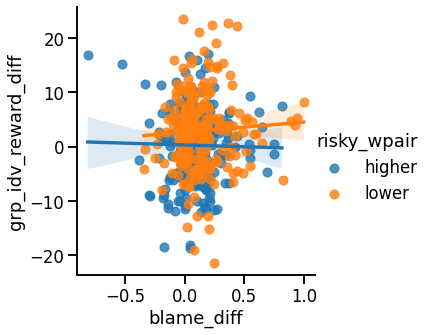

In [115]:
t = df_group.query('selfBlame!=-1').groupby(['subID', 'attack', 'predatorType'], as_index=False)['selfBlame'].mean()
t = pd.merge(t.query('attack==False'), t.query('attack==True'), on=['subID', 'predatorType'])
t['blame_diff'] = t['selfBlame_x'] - t['selfBlame_y']
print(len(t))
# t = pd.merge(df_perf.groupby('sub', as_index=False)['grp_idv_reward_diff'].mean(), t)
t = pd.merge(df_perf, t, how='right')
print(len(t))
sns.lmplot(data=t, x='blame_diff', y='grp_idv_reward_diff', hue='risky_wpair')
print(ss.pearsonr(t.query('risky_wpair=="lower"')['blame_diff'], t.query('risky_wpair=="lower"')['grp_idv_reward_diff']))
print(ss.pearsonr(t.query('risky_wpair=="higher"')['blame_diff'], t.query('risky_wpair=="higher"')['grp_idv_reward_diff']))

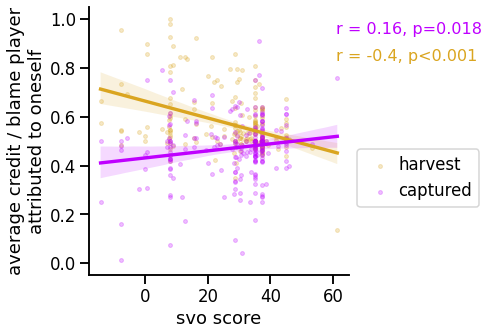

In [116]:
d = df_group.query('selfBlame!=-1').groupby(['subID', 'attack'],as_index=False)['selfBlame'].mean()
d = pd.merge(d, data[['subID', 'svo_value', 'ius_score', 'trait']].drop_duplicates())

outcome_palette = ['goldenrod', "#bf00ff"]
d['outcome'] = d['attack'].apply(lambda x: 'captured' if x else 'harvest')
#plot
g = sns.lmplot(data = d, x='svo_value', y='selfBlame', hue='outcome',
           scatter_kws={'s':15, 'alpha':0.25}, palette=outcome_palette, legend=None)

rt, pt = ss.pearsonr(d.query('attack==True')['svo_value'], 
                  d.query('attack==True')['selfBlame'])
rf, pf = ss.pearsonr(d.query('attack==False')['svo_value'], 
                  d.query('attack==False')['selfBlame'])
pt = f'={round(pt,3)}' if pt>0.001 else '<0.001'
pf = f'={round(pf,3)}' if pf>0.001 else '<0.001'
plt.annotate(f"r = {round(rt,2)}, p{pt}", xy=(0.95, 0.9), xycoords='axes fraction',
             color=outcome_palette[1], fontsize=16)
plt.annotate(f"r = {round(rf,2)}, p{pf}", xy=(0.95, 0.8), xycoords='axes fraction',
             color=outcome_palette[0], fontsize=16)
plt.legend(bbox_to_anchor=(1.0, 0.5), handletextpad=0.1)
plt.ylim([-0.05, 1.05])
plt.ylabel("average credit / blame player\nattributed to oneself")
plt.xlabel('svo score')
# plt.tight_layout()
plt.savefig(f'../paper_figs/{folder}/blame_svo_{folder}.png',
            dpi=200, bbox_inches='tight')

In [117]:

# import statsmodels.formula.api as smf

# # Run the regression using the formula
# model = smf.ols(formula='svo_value ~ risky_wpair', data=data)

# result = model.fit()

# # Print the summary of the model
# print(result.summary())

In [118]:
# no correlation
# sns.lmplot(data = data, x='ius_score', y='playerKeep2', hue='predatorType')
# plt.figure()
# sns.lmplot(data = data, x='trait', y='playerKeep2', hue='predatorType')

# sns.lmplot(data = data, x='svo_value', y='grp_idv_step_diff', hue='predatorType')
# sns.regplot(data=data.query('risky_wpair=="lower"'), y='grp_idv_step_diff', x='svo_value')
# sns.regplot(data=data.query('risky_wpair=="higher"'), y='grp_idv_step_diff', x='svo_value')
# plt.figure()
# sns.lmplot(data = data, x='trait', y='playerKeep2', hue='predatorType')

ius: PearsonRResult(statistic=-0.1278191657185538, pvalue=0.055560308018074635)
trait anxiety: PearsonRResult(statistic=-0.12145741385144232, pvalue=0.06899510972234726)


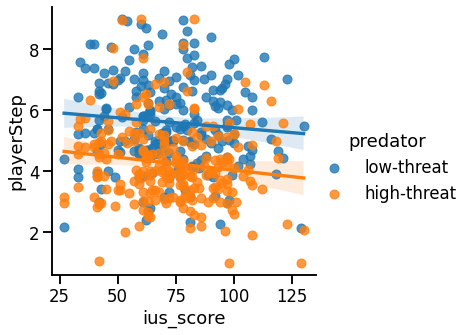

<Figure size 432x288 with 0 Axes>

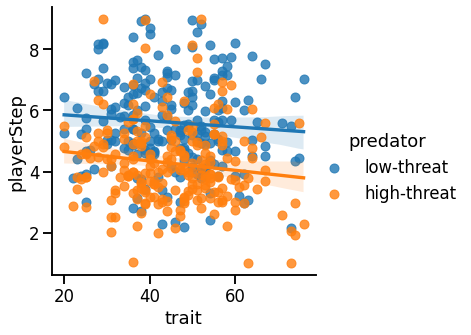

In [119]:
#ius and stai
sns.lmplot(data = data, x='ius_score', y='playerStep', hue='predator')
plt.figure()
sns.lmplot(data = data, x='trait', y='playerStep', hue='predator')

d = data.groupby('subID')[['ius_score','playerStep']].mean()
print(f"ius: {ss.pearsonr(d['ius_score'], d['playerStep'])}")
d = data.groupby('subID')[['trait','playerStep']].mean()
print(f"trait anxiety: {ss.pearsonr(d['trait'], d['playerStep'])}")

trait anxiety: PearsonRResult(statistic=-0.00440817045608265, pvalue=0.9475732132603397)


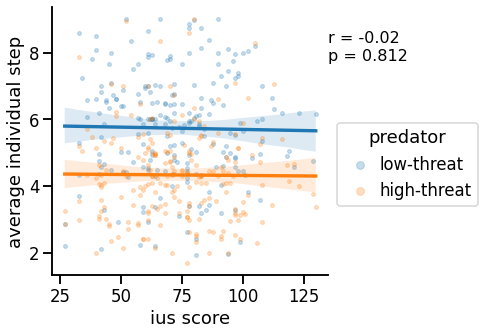

<Figure size 432x288 with 0 Axes>

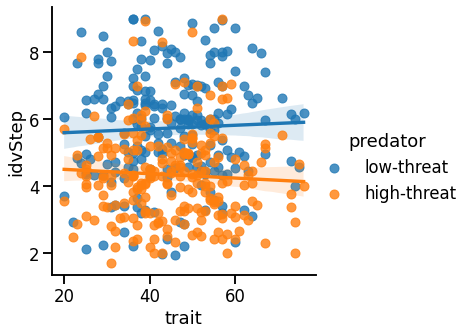

In [120]:
#ius and stai
sns.lmplot(data = data, x='ius_score', y='idvStep', hue='predator'
           , scatter_kws={'s':15, 'alpha':0.25}, legend=None)
d = data.groupby('subID')[['ius_score','idvStep']].mean()
r, p = ss.pearsonr(d['ius_score'], d['idvStep'])
plt.annotate(f'r = {r:.2f}\np = {p:.3f}', xy=(1, 0.8), xycoords = 'axes fraction', fontsize=16)

plt.ylabel('average individual step')
plt.xlabel('ius score')

plt.legend(markerscale=2, title='predator', bbox_to_anchor=(1, 0.6), handletextpad=0.2) 
# plt.tight_layout()
plt.savefig(f'../paper_figs/{folder}/ius_idvstep_{folder}.png', 
            dpi=200, bbox_inches='tight')

plt.figure()
sns.lmplot(data = data, x='trait', y='idvStep', hue='predator')
r_value, p_value = ss.pearsonr(data['ius_score'], data['idvStep'])
d = data.groupby('subID')[['trait','idvStep']].mean()
print(f"trait anxiety: {ss.pearsonr(d['trait'], d['idvStep'])}")


trait anxiety: PearsonRResult(statistic=-0.13890558043254933, pvalue=0.03733491309605756)


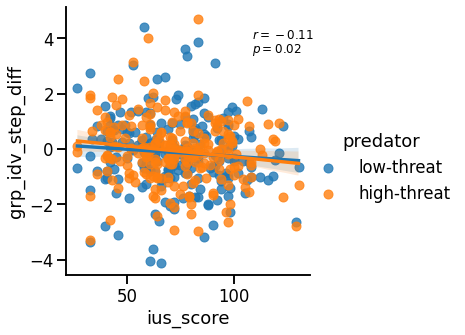

<Figure size 432x288 with 0 Axes>

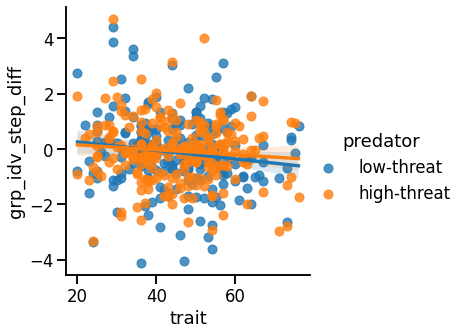

In [121]:
#ius and stai
sns.lmplot(data = data, x='ius_score', y='grp_idv_step_diff', hue='predator')
r_value, p_value = ss.pearsonr(data['ius_score'], data['grp_idv_step_diff'])
myright = (plt.gca().get_xlim()[1]) * 0.8
plt.text(myright, 4, f'$r = {r_value:.2f}$', fontsize=12)
if p_value>=0.001:
    plt.text(myright, 3.5, f'$p = {p_value:.2f}$', fontsize=12)
else:
    plt.text(myright, 3.5, f'$p < 0.001$', fontsize=12)



plt.figure()
sns.lmplot(data = data, x='trait', y='grp_idv_step_diff', hue='predator')

d = data.groupby('subID')[['trait','grp_idv_step_diff']].mean()
print(f"trait anxiety: {ss.pearsonr(d['trait'], d['grp_idv_step_diff'])}")

In [122]:
# quantile_data = data.copy()
# quantile_data['ius_score'] = pd.cut(quantile_data['ius_score'], 
#                                     bins= np.arange(20, 130, 10),
#                                     labels= np.arange(30, 130, 10))
# # quantile_data = quantile_data.groupby('ius_score')
# sns.lineplot(data = quantile_data, x='ius_score', y='player_partner_diff')

group money: PearsonRResult(statistic=-0.07800883066269101, pvalue=0.24386042734069457)
idv money: PearsonRResult(statistic=0.0737491219809205, pvalue=0.2706460096899627)


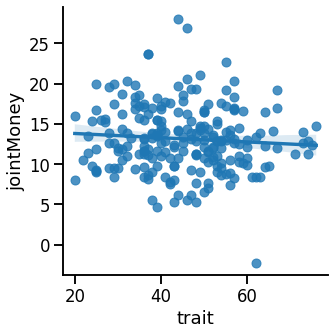

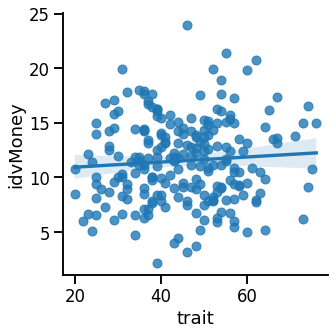

In [123]:
d2 = data.groupby(['subID', 'trait'], 
                  as_index=False)[['jointMoney', 'idvMoney']].mean()
sns.lmplot(data =  d2,
           x='trait', y='jointMoney')

sns.lmplot(data = d2,
           x='trait', y='idvMoney')

print(f"group money: {ss.pearsonr(d2['trait'], d2['jointMoney'])}")
print(f"idv money: {ss.pearsonr(d2['trait'], d2['idvMoney'])}")

trait anxiety: PearsonRResult(statistic=-0.12777041305642894, pvalue=0.05565436521311955)


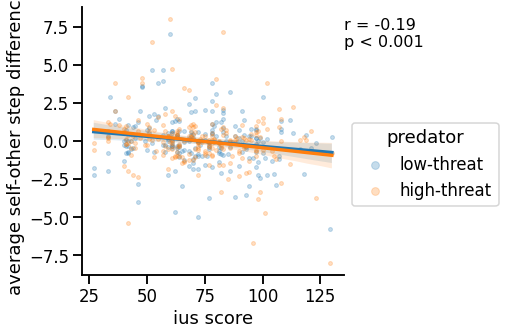

<Figure size 432x288 with 0 Axes>

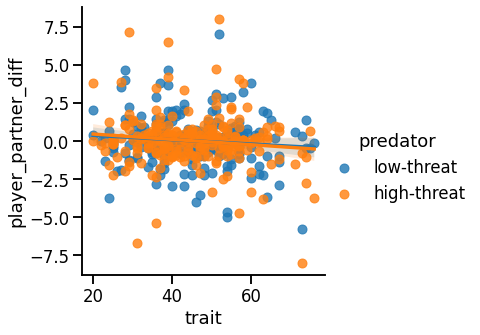

In [124]:
# player partner step difference with ius
data['player_partner_diff'] = data['playerStep'] - data['partnerStep']

sns.lmplot(data = data, x='ius_score', y='player_partner_diff', hue='predator'
           ,scatter_kws={'s':15, 'alpha':0.25}, legend=None)
r_value, p_value = ss.pearsonr(data['ius_score'], data['player_partner_diff'])
p = f'p = {p_value:.3f}' if p_value>0.001 else 'p < 0.001'
plt.annotate(f'r = {r_value:.2f}\n{p}', xy=(1, 0.85), xycoords='axes fraction', fontsize=16)

plt.ylabel('average self-other step difference')
plt.xlabel('ius score')
plt.legend(markerscale=2, title='predator', bbox_to_anchor=(1, 0.6), handletextpad=0.5) 
# plt.legend(markerscale=2, title='predator', bbox_to_anchor=(1, 0.6)) 

plt.savefig(f'../paper_figs/{folder}/ius_grpstep_{folder}.png', 
            dpi=200, bbox_inches='tight')


plt.figure()
sns.lmplot(data = data, x='trait', y='player_partner_diff', hue='predator')
d = data.groupby('subID')[['trait','player_partner_diff']].mean()
print(f"trait anxiety: {ss.pearsonr(d['trait'], d['player_partner_diff'])}")

PearsonRResult(statistic=-0.11055831668793623, pvalue=0.09808427033633563)

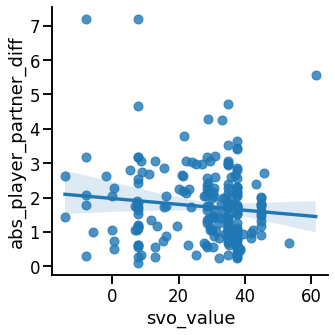

In [125]:
d = data.groupby(['subID', 'svo_value'], as_index=False)['abs_player_partner_diff'].mean()
sns.lmplot(data = d, x='svo_value', y='abs_player_partner_diff')
ss.pearsonr(d['svo_value'], d['abs_player_partner_diff'])

In [126]:
# svo ~ abs_player_partner_diff + risky_wpair

PearsonRResult(statistic=0.04842635620208008, pvalue=0.30535261260846186)

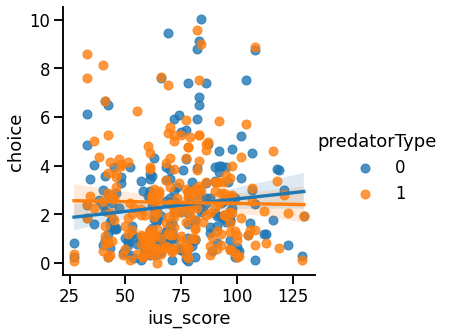

In [127]:
#look at exploration and ius
X = 60
d = df_idv.query('trial<@X').groupby(['subID', 'predatorType'], as_index=False)['choice'].var()
d = pd.merge(d, qs_orig[['subID', 'ius_score']].drop_duplicates())
sns.lmplot(data = d, x='ius_score', y='choice', hue='predatorType')
ss.pearsonr(d['ius_score'], d['choice'])

<Axes: xlabel='trait', ylabel='grp_idv_step_diff'>

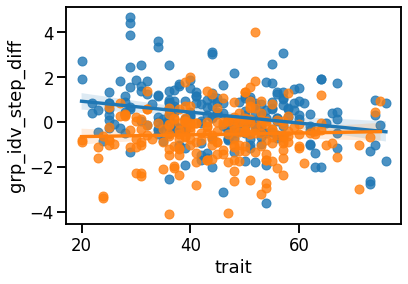

In [128]:
data['compromise'] = data.apply(lambda x: True if ((x['grp_idv_step_diff']>0 and x['risky_wpair']=='lower')\
                                                   or (x['grp_idv_step_diff']<0 and x['risky_wpair']=='higher')) \
                                                    else False, axis=1)
d = data.groupby(['subID', 'predatorType', 'compromise'], as_index=False)[['trait', 'ius_score']].mean()
# sns.pointplot(data = d, x='compromise', y='trait')

sns.regplot(data=data.query('risky_wpair=="lower"'), y='grp_idv_step_diff', x='trait')
sns.regplot(data=data.query('risky_wpair=="higher"'), y='grp_idv_step_diff', x='trait')

pearson: PearsonRResult(statistic=-0.38389687143085766, pvalue=2.5821143685883064e-09)
pearson: PearsonRResult(statistic=-0.12236633050637462, pvalue=0.06692716353857855)


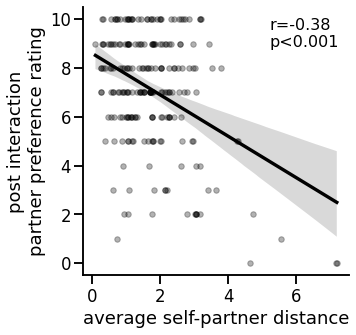

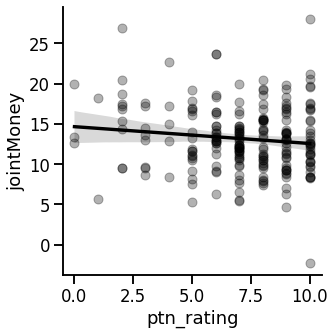

In [129]:
# d = data.groupby('subID')[['ptn_rating', 'partnerStep_var']].mean().dropna()
# sns.lmplot(data = d, x='ptn_rating', y='partnerStep_var')
# print(f"pearson: {ss.pearsonr(d['ptn_rating'], d['partnerStep_var'])}")


# plt.figure(figsize=(6, 4))
d = data.groupby('subID')[['ptn_rating', 'abs_player_partner_diff']].mean().dropna()
sns.lmplot(data = d, y='ptn_rating', x='abs_player_partner_diff', 
           scatter_kws={'alpha':0.3, 'color':'black', 's':30}, line_kws={'color':'black'})
print(f"pearson: {ss.pearsonr(d['ptn_rating'], d['abs_player_partner_diff'])}")
r, p = ss.pearsonr(d['ptn_rating'], d['abs_player_partner_diff'])
p = f"p={round(p, 3)}" if p>=0.001 else "p<0.001"
plt.ylabel('post interaction\npartner preference rating')
plt.xlabel('average self-partner distance')
# plt.annotate(fr"$r={round(r, 3)} {p}$", xy=(5, 7), fontsize=14)
plt.annotate(f"r={round(r, 2)}\n{p}", xy=(0.7, 0.85), xycoords = 'axes fraction', fontsize=16)
plt.savefig(f'../paper_figs/{folder}/ptn_rating_{folder}.png',
            dpi=200, bbox_inches='tight')

# data['step_inc_towards_partner'] = data.appl(lambda row: row['grp_idv_step_diff'] if row['self_partner_risk_diff']<0 else -row['grp_idv_step_diff'], axis=1)
# d = data.groupby('subID')[['ptn_rating', 'step_inc_towards_partner']].mean().dropna()
# sns.lmplot(data = d, x='ptn_rating', y='step_inc_towards_partner')
# print(f"pearson: {ss.pearsonr(d['ptn_rating'], d['step_inc_towards_partner'])}")

# what about money?
d = data.groupby('subID')[['ptn_rating', 'jointMoney']].mean().dropna()
sns.lmplot(data = d, x='ptn_rating', y='jointMoney', 
           scatter_kws={'alpha':0.3, 'color':'black'}, line_kws={'color':'black'})
print(f"pearson: {ss.pearsonr(d['ptn_rating'], d['jointMoney'])}")

In [130]:
#social benefit2: higher ptn_rating
import statsmodels.formula.api as smf

# Run the regression using the formula
model = smf.ols(formula='ptn_rating ~ abs_player_partner_diff + jointMoney', 
                data=data.groupby(['subID'], as_index=False)[['ptn_rating', 'abs_player_partner_diff', 'jointMoney']].mean())

result = model.fit()

# Print the summary of the model
print(result.summary())



                            OLS Regression Results                            
Dep. Variable:             ptn_rating   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     21.48
Date:                Sat, 02 May 2026   Prob (F-statistic):           2.96e-09
Time:                        17:52:53   Log-Likelihood:                -493.21
No. Observations:                 225   AIC:                             992.4
Df Residuals:                     222   BIC:                             1003.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

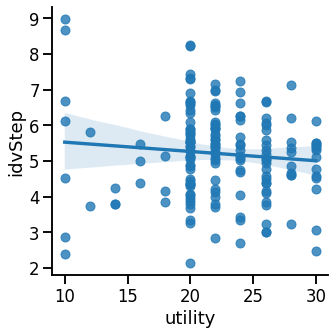

<Figure size 432x288 with 0 Axes>

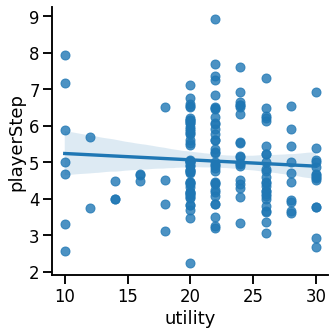

In [131]:
d = data.groupby('subID')[['utility', 'idvStep', 'playerStep']].mean()
sns.lmplot(data=d, x='utility', y='idvStep')
plt.figure()
sns.lmplot(data=d, x='utility', y='playerStep')

pearson: PearsonRResult(statistic=-0.06935584365377599, pvalue=0.30029966609999664)


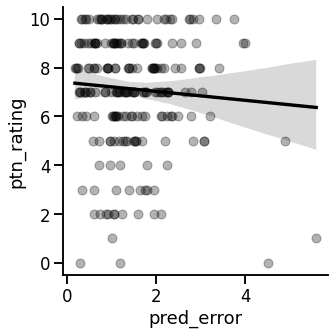

In [132]:
d2 = (
    (df_group['prediction'] - df_group['partnerStep'])
    .abs()
    .groupby(df_group['subID'])
    .mean()
    .reset_index(name='pred_error')
)
d = data.groupby('subID', as_index=False)[['ptn_rating', 'abs_player_partner_diff']].mean().dropna()
d = pd.merge(d, d2)
sns.lmplot(data = d, y='ptn_rating', x='pred_error', 
           scatter_kws={'alpha':0.3, 'color':'black'}, line_kws={'color':'black'})
print(f"pearson: {ss.pearsonr(d['ptn_rating'], d['pred_error'])}")


# Optimality

In [104]:
df_perf.columns

Index(['room', 'predatorType', 'selfBlame', 'blame_async', 'subID',
       'abs_player_partner_diff', 'idvStep', 'idvMoney', 'idv_attack',
       'playerStep', 'jointMoney', 'finalStep', 'partnerStep', 'attack',
       'risky_wpair', 'risky_abs', 'grp_idv_step_diff', 'grp_idv_reward_diff',
       'grp_idv_attack_diff', 'self_partner_risk_diff', 'abs_prediction_error',
       'playerStep_var', 'partnerStep_var', 'idvStep_var', 'finalStep_var',
       'abs_ppd_var'],
      dtype='object')

In [105]:

df_perf['predator'] = df_perf['predatorType'].apply(lambda x: 'high-threat' if x==1 else 'low-threat')
df_perf['deviation_from_optimal'] = df_perf.apply(lambda row: row['idvStep']-5 if row['predatorType']==1 else row['idvStep']-8, axis=1)
df_perf['step_inc_towards_partner'] = df_perf.apply(lambda row: row['grp_idv_step_diff'] if row['risky_wpair']=='risk-averse' else -row['grp_idv_step_diff'], axis=1)
risk_palette = {'lower': 'teal', 'higher': 'salmon'}

In [106]:
# sns.lmplot(data = df_perf, x='deviation_from_optimal', y='step_inc_towards_partner', hue='risky_wpair',
#            scatter_kws={'s':12, 'alpha':0.25}, palette=risk_palette)
# plt.axhline(0, ls='--', lw=0.8, color='black')
# plt.axvline(0, ls='--', lw=0.8, color='black')
# plt.ylabel('compromise')

high-threat: 
PearsonRResult(statistic=-0.12110169983704713, pvalue=0.05584624094583108)
low-threat: 
PearsonRResult(statistic=-0.4828566265031045, pvalue=5.23570829493022e-16)


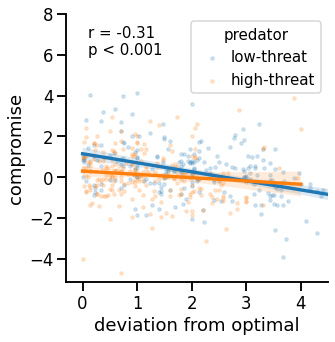

In [107]:
# sns.lmplot(data = group_stat, x='deviation_from_optimal', y='step_inc_directed', hue='risky_wpair',
#            scatter_kws={'s':15, 'alpha':0.2}, palette=risk_palette)

d = df_perf.copy()
d['deviation_from_optimal'] = np.abs(d['deviation_from_optimal'])
sns.lmplot(data = d, x='deviation_from_optimal', y='step_inc_towards_partner', hue='predator',
           scatter_kws={'s':12, 'alpha':0.2}, legend=False)
plt.ylabel('compromise')
plt.xlabel('deviation from optimal')
print("high-threat: ")
print(ss.pearsonr(d.query('predatorType==1')['deviation_from_optimal'], 
                  d.query('predatorType==1')['step_inc_towards_partner']))
print("low-threat: ")
print(ss.pearsonr(d.query('predatorType==0')['deviation_from_optimal'], 
                  d.query('predatorType==0')['step_inc_towards_partner']))

r, p= ss.pearsonr(d['deviation_from_optimal'], d['step_inc_towards_partner'])
p = f"p = {round(p, 3)}" if p>0.001 else "p < 0.001"

plt.annotate(f"r = {round(r, 2)}\n{p}", xy=(0.1, 6), fontsize=15)
plt.legend(title='predator', handletextpad=0.2, fontsize=15, title_fontsize=15)
plt.xlim(right=4.5)
plt.ylim(top = 8)

plt.savefig(f'../paper_figs/{folder}/compromise_optimal_{folder}.png', 
            bbox_inches='tight', dpi=200)

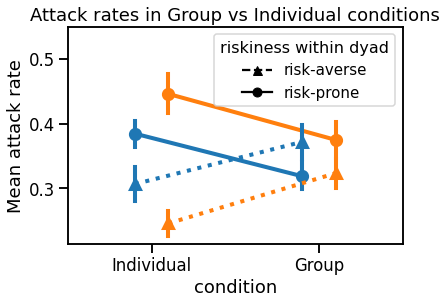

In [108]:
from matplotlib.lines import Line2D

# Compute means
df_grp_mean = (
    df_group.groupby(['subID', 'predatorType'], as_index=False)['attack']
    .mean()
    .assign(condition='Group')
)

df_idv_mean = (
    df_idv.groupby(['subID', 'predatorType'], as_index=False)['attack']
    .mean()
    .assign(condition='Individual')
)

# Combine
df_all = pd.concat([df_idv_mean, df_grp_mean], ignore_index=True)
df_all = pd.merge(df_all, df_perf[['subID', 'predator', 'risky_wpair', 'predatorType']], how='left')
# Plot
plt.figure(figsize=(6,4))
sns.pointplot(
    data=df_all.query('risky_wpair=="higher"'),
    hue='predator',
    y='attack',
    x='condition',
    legend=False,
    dodge=0.2
    # ci='ci'   # or "se" / None, depending on what you want
)

sns.pointplot(
    data=df_all.query('risky_wpair=="lower"'),
    hue='predator',
    y='attack',
    x='condition',
    marker = '^',
    ls=':',
    legend=False,
    dodge=0.2
    # ci='ci'   # or "se" / None, depending on what you want
)
plt.ylabel("Mean attack rate")
plt.ylim(top=0.55)
# plt.xlabel("Predator type")
plt.title("Attack rates in Group vs Individual conditions")
legend_handles = [
    Line2D([0], [0], color='black', ls='--', marker='^', label='risk-averse'),
    Line2D([0], [0], color='black', ls='-', marker='o', label='risk-prone')
]
plt.legend(handles = legend_handles, title='riskiness within dyad', title_fontsize=16, fontsize=15)



In [109]:
# sns.barplot(data = df_group.query('(predatorType==0 and finalStep==8) or (predatorType==1 and finalStep==5)'), x='predatorType', y='attack')
# sns.barplot(data = df_group.groupby(['subID', 'predatorType'], as_index=False)['attack'].mean(), x='predatorType', y='attack')
# sns.barplot(data = df_idv.groupby(['subID', 'predatorType'], as_index=False)['attack'].mean(), x='predatorType', y='attack')

# 1. Prepare your three datasets with a new column "source"
# d1 = df_group.query('(predatorType==0 and finalStep==8) or (predatorType==1 and finalStep==5)').copy()
# d1['source'] = "optimal"

# d2 = df_group.groupby(['subID', 'predator'], as_index=False)['attack'].mean()
# d2['source'] = "dyad"

# d3 = df_idv.groupby(['subID', 'predator'], as_index=False)['attack'].mean()
# d3['source'] = "individual"

# # 2. Combine
# df_all = pd.concat([d1[['predator','attack','source']],
#                     d3[['predator','attack','source']],
#                     d2[['predator','attack','source']]])

# # 3. Plot
# plt.figure(figsize=(5,5))
# sns.pointplot(data=df_all, hue='predator', y='attack', x='source', hue_order=['low-threat', 'high-threat'])
# plt.ylabel("frequency of captures")
# plt.xlabel("")
# # plt.title("Attack by predator type across datasets")
# plt.legend(title="predator")
# plt.axhline(optimal_att[0], ls='--')
# plt.axhline(optimal_att[1], ls='--')
# if save:
#     plt.savefig(f'../paper_figs/{folder}/attack_prob_{folder}.png', 
#                 bbox_inches='tight', dpi=200)

# RF for cluster prediction

In [370]:
print(data.columns)

Index(['room', 'predatorType', 'selfBlame', 'blame_async', 'subID',
       'abs_player_partner_diff', 'idvStep', 'idvMoney', 'idv_attack',
       'playerStep', 'jointMoney', 'finalStep', 'partnerStep', 'attack',
       'risky_wpair', 'risky_abs', 'grp_idv_step_diff', 'grp_idv_reward_diff',
       'grp_idv_attack_diff', 'self_partner_risk_diff', 'abs_prediction_error',
       'playerStep_var', 'partnerStep_var', 'idvStep_var', 'finalStep_var',
       'abs_ppd_var', 'sub', 'sub_full', 'ptn_rating', 'svo_value', 'svo_type',
       'utility', 'trait', 'ius_score', 'predator', 'player_partner_diff',
       'compromise'],
      dtype='object')


In [371]:
data["grp_idv_step_diff_risk_prone"] = np.where(
    data["risky_wpair"] == "higher",
    data["grp_idv_step_diff"],
    0
)

data["grp_idv_step_diff_risk_averse"] = np.where(
    data["risky_wpair"] == "lower",
    data["grp_idv_step_diff"],
    0
)

#add ego_bias
t = df_group.query('selfBlame!=-1').groupby(['subID', 'room', 'attack', 'predatorType'], as_index=False)['selfBlame'].mean()
t = pd.merge(t.query('attack==0').rename({'selfBlame':'selfBlame_noAttack'}, axis=1),
             t.query('attack==1').rename({'selfBlame':'selfBlame_attack'}, axis=1),
             on=['subID', 'room', 'predatorType'])
t['ego_bias'] =  t['selfBlame_noAttack'] - (1-t['selfBlame_attack'])
data = pd.merge(data, t[['subID', 'room', 'predatorType', 'ego_bias']], on=['subID', 'room', 'predatorType'])


collapsed_g = (
    data
    .groupby(['room', 'predatorType'])
    .agg(
        idvStep_diff = ('idvStep', lambda x: x.iloc[-1] - x.iloc[0]),
        ego_bias_diff = ('ego_bias', lambda x: x.iloc[-1] - x.iloc[0]),
        jointMoney_mean = ('jointMoney', 'mean'),
        finalStep = ('finalStep', 'first'),
        grp_idv_step_diff_risk_prone = ('grp_idv_step_diff_risk_prone', 'sum'),
        grp_idv_step_diff_risk_averse = ('grp_idv_step_diff_risk_averse', 'sum'),
        idvStep_mean = ('idvStep', 'mean'),
        blame_async = ('blame_async', 'mean'),
        ego_bias_mean = ('ego_bias', 'mean') 
    )
    .reset_index()
)



def get_cluster(row):
    if row['grp_idv_step_diff_risk_prone'] >0:
        if row['grp_idv_step_diff_risk_averse'] >0:
            cluster = "risk increase"
        else:
            cluster = "risk diverge"
    else:
        if row['grp_idv_step_diff_risk_averse'] <0:
            cluster = "risk decrease"
        else:
            cluster = "risk converge"
    return cluster
# add category
collapsed_g['cluster'] = collapsed_g.apply(get_cluster, axis=1)



collapsed_g

,room,predatorType,idvStep_diff,ego_bias_diff,jointMoney_mean,finalStep,grp_idv_step_diff_risk_prone,grp_idv_step_diff_risk_averse,idvStep_mean,blame_async,ego_bias_mean,cluster
0,1,0,-1.266667,-0.572917,17.400000,4.966667,-2.033333,-1.766667,6.466667,0.129167,0.161458,risk decrease
1,1,1,2.600000,0.010870,9.933333,4.000000,-1.333333,1.233333,3.933333,0.129167,-0.005435,risk converge
2,2,0,0.000000,0.000000,32.066667,7.766667,1.066667,0.000000,6.100000,0.125000,0.006944,risk diverge
3,2,1,0.000000,0.000000,8.966667,3.666667,-1.233333,0.000000,4.633333,0.125000,0.031250,risk converge
4,3,0,2.533333,0.442793,17.189655,6.965517,1.552874,0.879310,5.766667,0.354167,0.242889,risk increase
...,...,...,...,...,...,...,...,...,...,...,...,...
241,130,1,0.666667,0.041667,10.266667,4.733333,0.066667,0.600000,4.300000,0.062500,0.020833,risk increase
242,131,0,0.966667,0.132963,14.253704,4.966667,-1.051852,0.133333,5.050000,0.179167,-0.008916,risk converge
243,131,1,-2.266667,-0.088450,9.196296,3.933333,-0.900000,1.059259,3.666667,0.179167,0.021116,risk converge
244,132,0,1.300000,0.114583,28.292308,6.033333,-0.417949,-0.366667,6.383333,0.416667,-0.255208,risk decrease


In [372]:

collapsed_g.groupby('cluster').size()

cluster
risk converge    113
risk decrease     75
risk diverge      20
risk increase     38
dtype: int64


=== Classification Report (5-fold CV) ===
               precision    recall  f1-score   support

risk converge      0.494     0.363     0.418       113
risk decrease      0.327     0.227     0.268        75
 risk diverge      0.140     0.350     0.200        20
risk increase      0.164     0.263     0.202        38

     accuracy                          0.305       246
    macro avg      0.281     0.301     0.272       246
 weighted avg      0.363     0.305     0.321       246

=== Confusion Matrix (rows=true, cols=pred) ===


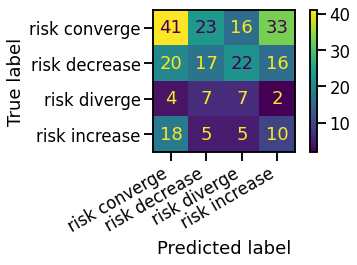


=== RandomForest feature importances ===
idvStep_mean     0.366688
ego_bias_mean    0.274051
idvStep_diff     0.191432
ego_bias_diff    0.167830
dtype: float64


In [373]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, f1_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# EXPECTED INPUT: one row per DYAD
# Required column: y_col = dyad category label (4 classes)
# Required predictors (edit these names to match your dataframe):
#   risk_A, risk_B: individual risk preferences (e.g., during individual phase)
#   ego_A,  ego_B : egocentric bias scores for each partner
# ------------------------------------------------------------

def predict_dyad_category(
    df: pd.DataFrame,
    feature_cols: list = None,
    y_col: str = "cluster",
    model_type: str = "rf",  # "logreg" or "rf"
    random_state: int = 0
):
    d = df.copy()

    # --- Basic dyad-level features from individual-level inputs ---

    # If you have "risk-averse" and "risk-prone" roles, you might prefer:
    # d["risk_averse"] = ...
    # d["risk_prone"]  = ...
    # and then use those directly instead of A/B.

    X = d[feature_cols]
    y = d[y_col].astype(str)  # ensure categorical

    # --- Choose model ---
    if model_type == "logreg":
        clf = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", LogisticRegression(
                multi_class="multinomial",
                solver="lbfgs",
                max_iter=5000,
                class_weight="balanced",  # helpful if classes imbalanced
                random_state=random_state
            ))
        ])
    elif model_type == "rf":
        
        clf = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=800,
                max_depth=None,
                min_samples_leaf=10,
                class_weight="balanced_subsample",
                random_state=random_state
            ))
        ])
    else:
        raise ValueError("model_type must be 'logreg' or 'rf'")

    # --- Cross-validated predictions (better than single split for reporting) ---
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    y_hat = cross_val_predict(clf, X, y, cv=cv)

    print("\n=== Classification Report (5-fold CV) ===")
    print(classification_report(y, y_hat, digits=3))

    print("=== Confusion Matrix (rows=true, cols=pred) ===")
    labels = sorted(y.unique())
    cm = confusion_matrix(y, y_hat, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(values_format="d")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    # --- Fit on full data to inspect coefficients/importance ---
    clf.fit(X, y)

    if model_type == "logreg":
        model = clf.named_steps["model"]
        coef = pd.DataFrame(model.coef_, columns=feature_cols, index=model.classes_)
        print("\n=== Multinomial LogReg coefficients (per class) ===")
        # show largest-magnitude coefficients per class
        for cls in coef.index:
            s = coef.loc[cls].sort_values(key=lambda v: np.abs(v), ascending=False)
            print(f"\nClass: {cls}")
            print(s.head(8))
    else:
        model = clf.named_steps["model"]
        imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
        print("\n=== RandomForest feature importances ===")
        print(imp.head(12))

    return clf, feature_cols


# --------------------
# Example usage:
# feature_cols = ["idvStep_diff", "idvStep_mean", "ego_bias", "blame_async"]
feature_cols = ["idvStep_diff", "idvStep_mean", "ego_bias_mean", "ego_bias_diff"]
clf, feats = predict_dyad_category(
    df=collapsed_g,
    feature_cols= feature_cols
)
